In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# least squares

def least_squares(x, y):
    n = len(x)
    m = (n*sum(x*y) - sum(x)*sum(y)) / (n*sum(x*x) - sum(x)**2)
    c = (sum(y) - m*sum(x)) / n

    return m, c

In [22]:
# polynomial fitting 

def poly_vander(x, y, degree=1):
    V = np.vander(x, N=degree+1, increasing=True)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients


In [26]:
# cubic spine


def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]               # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])      # Main diagonal
        C[i - 1] = h[i]                 # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])    # Right-hand side vector
    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


def cubic_spline(X, Y, step=0.01):
    "natural cubic spline solver"
    H = np.diff(X)

    # Set up the tridiagonal matrix for the cubic spline
    A, B, C, D = setup_tridiagonal_matrix(X, Y)

    M = [0, *thomas_algorithm(A, B, C, D), 0]

    # construct splines
    curves = [
        lambda x, M=M, H=H, X=X, Y=Y, i=i: (
            M[i]/6/H[i] * (X[i+1] - x)**3 + 
            M[i+1]/6/H[i] * (x - X[i])**3 +
            (Y[i]/H[i] - M[i]*H[i]/6) * (X[i+1] - x) +
            (Y[i+1]/H[i] - M[i+1]*H[i]/6) * (x - X[i])
        )
            for i in range(len(H))
    ]
    
    # solve cubic spline
    x_f = np.arange(X[0], X[-1], step)
    y_f = np.zeros(len(x_f))

    for i, x_i in enumerate(x_f):
        c_i = np.argmax(X>x_i) - 1
        y_f[i] = curves[c_i](x_i)
    
    return x_f, y_f


In [27]:
# define data; start = 2010 Q1, step = 1 Q

def x_from_yq(year, q):
    return year*4 + q

years = [0, 1, 2, 3, 4, 4, 5, 6, 6, 6, 7, 8, 9, 10, 10, 10, 11, 12, 13, 13]
quarters = [1, 1, 1, 1, 1, 3, 2, 1, 3, 4, 1, 1, 1, 1 ,2, 3, 1, 1, 2, 4]

assert(len(years) == len(quarters))

X = [x_from_yq(y, q) for y, q in zip(years, quarters)]
Y = [1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]

assert(len(X) == len(Y))


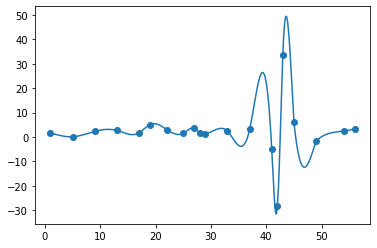

In [38]:
# Part A


# 1
# x_cubic, y_cubic = cubic_spline(X, Y, step=1)
x_cubic, y_cubic = cubic_spline(X, Y)


""" #1 discussion

The number of unknowns to solve for is len(X) - 2,
thus, there are 18 unknown second derivatives (M)

The continuity conditions at each interior knot 
are that the spline function is continuous and 
its first and second derivatives are also 
continuous at those knots.

The boundary conditions of a natural spline are 
that the second derivaties of the spline at the
endpoints are zero.
"""


# 2
plt.scatter(X, Y)
plt.plot(x_cubic, y_cubic)
plt.show()


""" #2 discussion

The interpolant is visually smooth. However, 
it does make some unreasonable assumptions,
especially around the outliers in the data, 
espcially at 2020 Q2 and 2020 Q3. The data
points show that there is only a slight dip
followed by a peak. The interpolant, however,
shows that there are three peaks, with the 
aforementioned original data points not even
being the extrema of the resultant graph.
Still, the interpolant is resonable enough
at lower magnitude points.
"""

# 3

""" #3 discussion

The Runge phenomenon makes it so that the model
at the outliers tends to oscillate, making them
poorer approximations than necessary. This is 
the tradeoff of having perfectly exact interpolations,
where the model directly goes through all datapoints
provided, at the cost of the model
deteriorating where data isn't available.

Smoothing splines would have the opposite problem
of cubic splines, as it would dampen outliers,
making the model underrepresent the real magnitude
of said outliers. Weighted least squares might be
preferrable, as it explicitly tries minimize the 
deviation of the model and the data. This would
help maintain the exactness of the interpolation,
while also keeping numerical stability. However,
it is an approximation, instead of an interpolation,
meaning that it would not exactly represent the data.
"""

pass

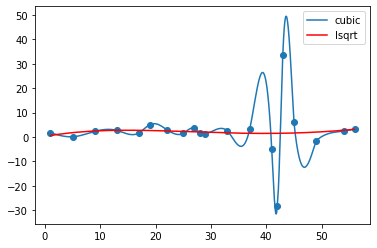

Linear Slope = 0.014732310498363871


In [72]:
# Part B

# 1

coeff = poly_vander(X, Y, 4)
poly = np.poly1d(coeff[::-1])

x_poly = np.arange(X[0], X[-1], 0.1)
y_poly = poly(x_poly)

plt.scatter(X, Y)
plt.plot(x_cubic, y_cubic, label="cubic")
plt.plot(x_poly, y_poly, 'r', label="lsqrt")
plt.legend()
plt.show()

""" #1 Discussion

The Least Square Root model better represents
the overall trend, while the cubic model better
reproduces all data points. This is the tradeoff
between approximation (lsqrt) and interpolation
(cubic). The cubic model has better fine grain
accuracy, but at the trade off of being less
accurate on a larger scale. Vice versa with the
lsqrt model.
"""

# 2

# exclude data
x_lin, y_lin = np.delete(np.copy(X), slice(13,16)), np.delete(np.copy(Y), slice(13,16))

m, c = least_squares(x_lin, y_lin)
print(f"Linear Slope = {m}")


""" #2 Discussion

The linear model has no significant economic
growth, with a slope very near 0. This makes
economic sense, as the overall trend of the
data is that of stagnation, with no major
growth over time. This, of course, requires
that you assume that there are no major
outliers in the data, as even one point
could change the overall slope to that of
predicting major growth/diminishment.
"""

pass

In [ ]:
# Part C

""" #1 Discussion

I would recommend a cubic spline fitting,
as the model would actually interpolate
between the two data points, instead of
merely approximating it. This would, as
a result, lead to a more accurate 
estimation which actually goes through
the two known data points. The tradeoff,
of course, would be that the model would
be more sensitive to outliers in the 
data. However, while this would be bad
on a long term scale, for a the purposes
of modeling the GDP growth in a singular
quarter, this sensitivity is desirable,
as it will actually reflect the growth
for the quarter, ceteris paribus. As
for smoothness, the polynomial fitting
model may be marginally smoother, but
the difference is negligible.
"""

""" Big O Addendum

Big O notation is a broad way to describe
the amount of time it takes for an algorithm
to run, specifically measuring how well it 
scales to larger amounts of data (time complexity). 

In regards to the time complexity of both
algorithms, the cubic fitting algorithm is only
O(n), while the polynomial fitting one is 
O(n²), owing to the use of a vandermond matrix. 
This data supports my decision to recommend a 
cubic spline.
"""

pass